# Compare: SAGE vs GAT vs LightGCN V4

Reads the SAGE/GAT sweep outputs (`results/old/<approach>/...`) and the LightGCN V4
sweep outputs (`../python_files/results/LightGcnV4/...`) and produces a unified analysis.

**Sections**
1. Setup
2. Per-quarter accuracy / F1 — SAGE vs GAT
3. Edge-column effect (`change_in_weight` vs `change_in_adjusted_weight`)
4. CUSIP rank analysis
    - 4.1 SAGE vs GAT ranking agreement (Spearman ρ, Kendall τ, top-K overlap)
    - 4.2 Rank evolution of top CUSIPs over time
    - 4.3 Per-CUSIP rank stability
5. Top-N CUSIP picks vs realised next-quarter return
6. LightGCN V4 results (AUC, AP, hit@K, NDCG@K, top-N return)
7. Cross-model comparison (SAGE vs GAT vs V4) on the bipartite × change_in_weight corner
8. Overall summary table
9. Overall statistics phase — plain-language digest
10. Model descriptions & core principles

## 1. Setup

In [35]:
import os
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, kendalltau, ttest_rel

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)

RESULTS_DIR = (Path("results") / "old").resolve()
DATA_DIR    = Path(os.environ.get("FGNN_DATA_DIR", str(Path.home() / "13Fgnn" / "data"))).expanduser().resolve()
V4_DIR      = (Path("..") / "python_files" / "results" / "LightGcnV4").resolve()

APPROACHES  = ["bipartite", "multiq_A", "multiq_B"]
EDGES_COLS  = ["change_in_weight", "change_in_adjusted_weight"]
MODELS      = ["sage", "gat"]

print("results :", RESULTS_DIR)
print("data    :", DATA_DIR)
print("v4 dir  :", V4_DIR)
for a, c in product(APPROACHES, EDGES_COLS):
    p = RESULTS_DIR / a / f"metrics__{c}.csv"
    print("  ", "OK " if p.exists() else "-- ", p.relative_to(RESULTS_DIR))
for f in ["sweep_results_v4__change_in_weight.csv", "cusip_ranks_v4__change_in_weight.parquet"]:
    p = V4_DIR / f
    print("  ", "OK " if p.exists() else "-- ", p.name)

results : C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\SocialNetwork\src\Korkevados\slumrun\results\old
data    : C:\Users\potda\13Fgnn\data
v4 dir  : C:\Users\potda\Daniel\BGU\Year_D\סמסטר ז\Final_Project\Social-Network-Stock-Market\SocialNetwork\src\Korkevados\python_files\results\LightGcnV4
   OK  bipartite\metrics__change_in_weight.csv
   OK  bipartite\metrics__change_in_adjusted_weight.csv
   OK  multiq_A\metrics__change_in_weight.csv
   OK  multiq_A\metrics__change_in_adjusted_weight.csv
   OK  multiq_B\metrics__change_in_weight.csv
   OK  multiq_B\metrics__change_in_adjusted_weight.csv
   OK  sweep_results_v4__change_in_weight.csv
   OK  cusip_ranks_v4__change_in_weight.parquet


In [36]:
def load_metrics(approach, edges_col):
    p = RESULTS_DIR / approach / f"metrics__{edges_col}.csv"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["approach"] = approach
    df["edges_col"] = edges_col
    return df


def load_scores(approach, edges_col):
    p = RESULTS_DIR / approach / f"cusip_scores__{edges_col}.parquet"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_parquet(p)
    df["approach"] = approach
    df["edges_col"] = edges_col
    return df


def load_v4_metrics():
    p = V4_DIR / "sweep_results_v4__change_in_weight.csv"
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)


def load_v4_scores():
    p = V4_DIR / "cusip_ranks_v4__change_in_weight.parquet"
    if not p.exists():
        return pd.DataFrame()
    df = pd.read_parquet(p)
    # Normalise V4 schema to match SAGE/GAT scores: keep `score` for downstream helpers.
    if "mean_score" in df.columns and "score" not in df.columns:
        df = df.rename(columns={"mean_score": "score"})
    return df


all_metrics = pd.concat([
    load_metrics(a, c) for a, c in product(APPROACHES, EDGES_COLS)
], ignore_index=True)
v4_metrics = load_v4_metrics()
print("sage/gat metric rows:", len(all_metrics))
print("v4 metric rows      :", len(v4_metrics))
all_metrics.head()

sage/gat metric rows: 268
v4 metric rows      : 47


,approach,edges_col,year,quarter,predicts_year,predicts_quarter,n_train_nodes,n_test_nodes,n_test_edges,Fdim,...,sage_acc,sage_f1,sage_stocks_acc,sage_inv_acc,gat_train_s,gat_peak_gb,gat_acc,gat_f1,gat_stocks_acc,gat_inv_acc
0,bipartite,change_in_weight,2013,4,2014,1,2187,2664,65880,13,...,0.342234,0.190670,0.341867,0.350000,1.030341,0.169590,0.333960,0.248047,0.335171,0.308333
1,bipartite,change_in_weight,2014,1,2014,2,2664,6122,1287880,13,...,0.355683,0.310597,0.338783,0.368436,0.933510,2.749091,0.359771,0.292758,0.341065,0.373888
2,bipartite,change_in_weight,2014,2,2014,3,6122,6208,1325260,13,...,0.432166,0.427808,0.417750,0.443240,5.637421,5.479541,0.425875,0.331769,0.374675,0.465203
3,bipartite,change_in_weight,2014,3,2014,4,6208,6280,1351252,13,...,0.345859,0.342592,0.338680,0.351467,5.796758,5.637594,0.366326,0.353442,0.347794,0.380803
4,bipartite,change_in_weight,2014,4,2015,1,6280,6294,1365064,13,...,0.384628,0.368819,0.367546,0.398217,5.988685,5.747556,0.320096,0.300835,0.345139,0.300173


## 2. Per-quarter accuracy / F1 — SAGE vs GAT

Six panels (3 approaches × 2 edge cols). Each panel plots SAGE and GAT accuracy
per quarter. Companion table shows mean, std, and paired-t p-value of
`(gat − sage)` accuracy across quarters where both are non-null.

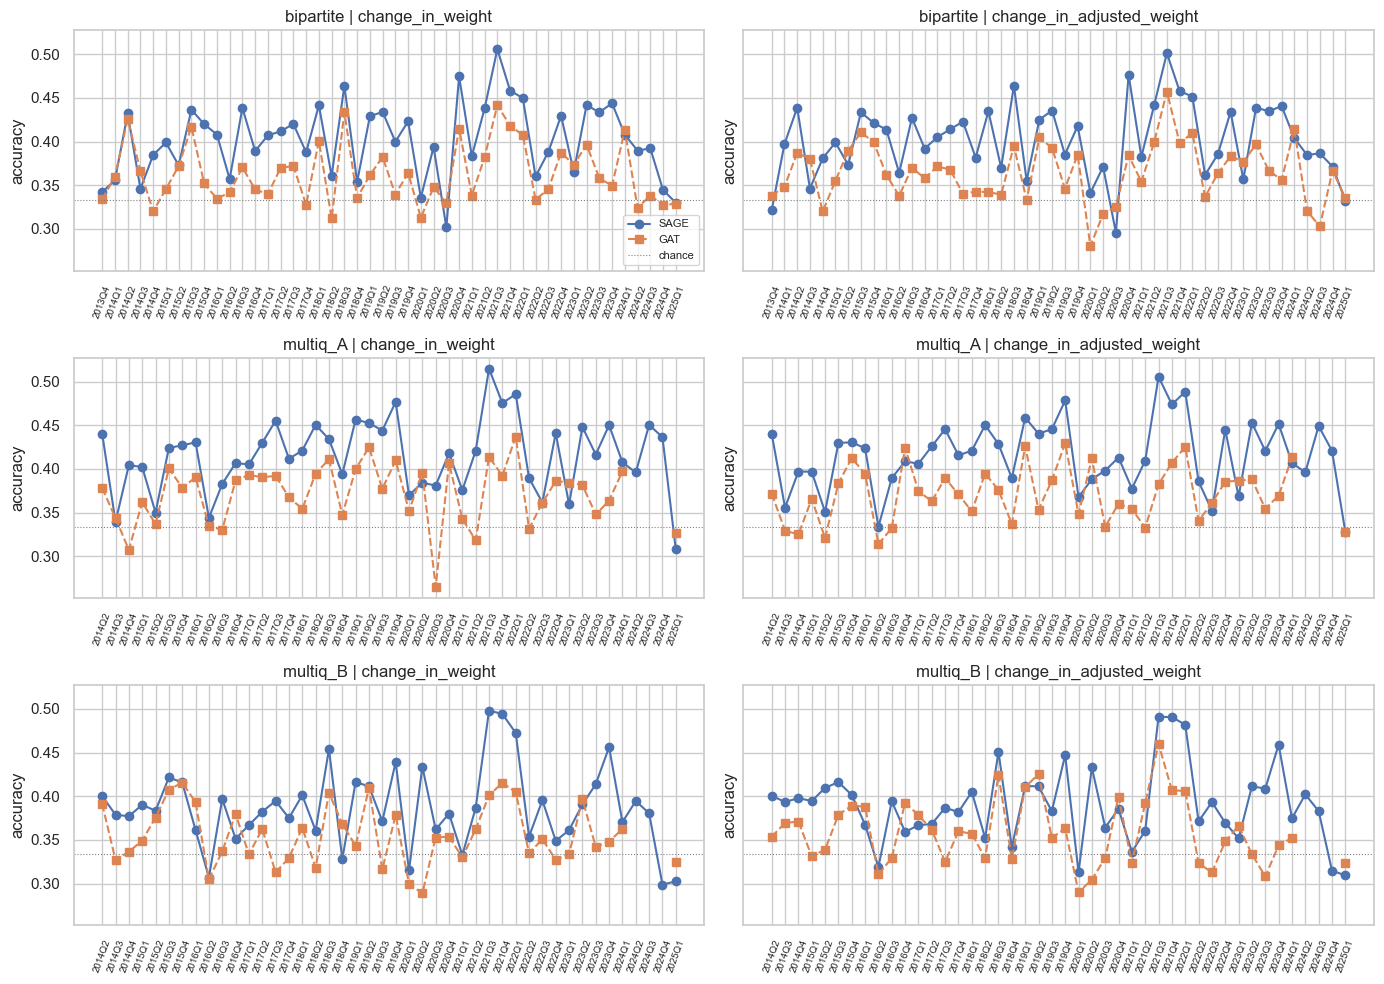

In [37]:
def quarter_label(row):
    return f"{int(row['year'])}Q{int(row['quarter'])}"

if not all_metrics.empty:
    fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey=True)
    for r, approach in enumerate(APPROACHES):
        for c, edges_col in enumerate(EDGES_COLS):
            ax = axes[r, c]
            d = all_metrics[(all_metrics["approach"] == approach) &
                              (all_metrics["edges_col"] == edges_col)].copy()
            if d.empty:
                ax.set_title(f"{approach} | {edges_col}  (no data)")
                continue
            d["q"] = d.apply(quarter_label, axis=1)
            d = d.sort_values(["year", "quarter"])
            ax.plot(d["q"], d["sage_acc"], marker="o", linestyle="-",
                    color="#4c72b0", label="SAGE")
            ax.plot(d["q"], d["gat_acc"], marker="s", linestyle="--",
                    color="#dd8452", label="GAT")
            ax.axhline(1/3, color="grey", linestyle=":", linewidth=0.8, label="chance")
            ax.set_title(f"{approach} | {edges_col}")
            ax.set_ylabel("accuracy")
            ax.tick_params(axis="x", rotation=70, labelsize=7)
            if r == 0 and c == 0:
                ax.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

In [38]:
rows = []
for approach, edges_col in product(APPROACHES, EDGES_COLS):
    d = all_metrics[(all_metrics.approach == approach) &
                      (all_metrics.edges_col == edges_col)][["year", "quarter", "sage_acc", "gat_acc"]].dropna()
    if len(d) < 2:
        rows.append({"approach": approach, "edges_col": edges_col, "n_quarters": len(d),
                     "sage_mean": np.nan, "gat_mean": np.nan, "diff_mean": np.nan, "t_pvalue": np.nan})
        continue
    stat = ttest_rel(d["gat_acc"], d["sage_acc"])
    rows.append({
        "approach": approach, "edges_col": edges_col,
        "n_quarters": len(d),
        "sage_mean": d["sage_acc"].mean(),
        "gat_mean":  d["gat_acc"].mean(),
        "diff_mean": (d["gat_acc"] - d["sage_acc"]).mean(),
        "t_pvalue": stat.pvalue,
    })
summary_2 = pd.DataFrame(rows).round(4)
summary_2

,approach,edges_col,n_quarters,sage_mean,gat_mean,diff_mean,t_pvalue
0,bipartite,change_in_weight,46,0.4018,0.3629,-0.0389,0.0
1,bipartite,change_in_adjusted_weight,46,0.4015,0.3644,-0.0372,0.0
2,multiq_A,change_in_weight,41,0.4143,0.3710,-0.0433,0.0
3,multiq_A,change_in_adjusted_weight,41,0.4145,0.3709,-0.0436,0.0
4,multiq_B,change_in_weight,41,0.3891,0.3557,-0.0333,0.0
5,multiq_B,change_in_adjusted_weight,41,0.3918,0.3583,-0.0335,0.0


## 3. Edge-column effect

Compare `change_in_weight` vs `change_in_adjusted_weight` within each (approach, model).

In [39]:
rows = []
for approach, model, edges_col in product(APPROACHES, MODELS, EDGES_COLS):
    d = all_metrics[(all_metrics.approach == approach) &
                      (all_metrics.edges_col == edges_col)]
    if d.empty:
        continue
    rows.append({
        "approach": approach, "model": model, "edges_col": edges_col,
        "acc_mean": d[f"{model}_acc"].mean(),
        "acc_std":  d[f"{model}_acc"].std(),
        "f1_mean":  d[f"{model}_f1"].mean(),
        "n":        int(d[f"{model}_acc"].notna().sum()),
    })
edge_eff = pd.DataFrame(rows).round(4)
edge_eff

,approach,model,edges_col,acc_mean,acc_std,f1_mean,n
0,bipartite,sage,change_in_weight,0.4018,0.0430,0.3851,46
1,bipartite,sage,change_in_adjusted_weight,0.4015,0.0425,0.3862,46
2,bipartite,gat,change_in_weight,0.3629,0.0344,0.3131,46
3,bipartite,gat,change_in_adjusted_weight,0.3644,0.0339,0.3186,46
4,multiq_A,sage,change_in_weight,0.4152,0.0423,0.4012,44
5,multiq_A,sage,change_in_adjusted_weight,0.4150,0.0401,0.3999,44
6,multiq_A,gat,change_in_weight,0.3710,0.0351,0.3336,41
7,multiq_A,gat,change_in_adjusted_weight,0.3709,0.0322,0.3353,41
8,multiq_B,sage,change_in_weight,0.3870,0.0460,0.3745,44
9,multiq_B,sage,change_in_adjusted_weight,0.3901,0.0438,0.3770,44


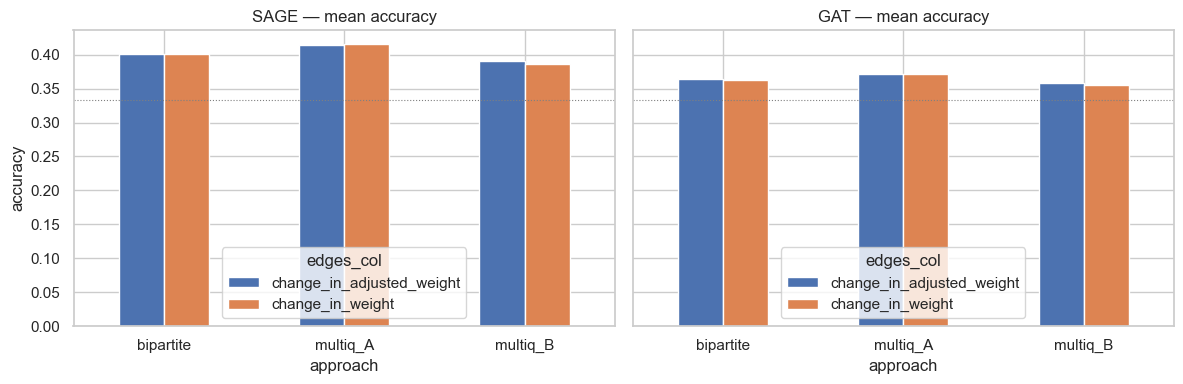

In [40]:
if not edge_eff.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    for ax, model in zip(axes, MODELS):
        sub = edge_eff[edge_eff.model == model].pivot(index="approach", columns="edges_col", values="acc_mean")
        sub.plot.bar(ax=ax, rot=0)
        ax.set_title(f"{model.upper()} — mean accuracy")
        ax.axhline(1/3, color="grey", linestyle=":", linewidth=0.8)
        ax.set_ylabel("accuracy")
    plt.tight_layout(); plt.show()

## 4. CUSIP rank analysis

Each `cusip_scores__*.parquet` row carries an explicit `rank` column (1 = top
score per quarter per model). § 4.1 measures *how much* SAGE and GAT agree;
§ 4.2 plots how individual top CUSIPs move over time per model; § 4.3 ranks
CUSIPs by stability of their top placement across the panel.

### 4.1 SAGE vs GAT ranking agreement

Per (approach × edge_col × quarter), inner-join SAGE and GAT scores on `cusip` and
compute Spearman ρ, Kendall τ, and top-K overlap (K ∈ {10, 25, 50, 100}).

In [41]:
def topk_overlap(a_sorted, b_sorted, k):
    return len(set(a_sorted[:k]) & set(b_sorted[:k])) / k

agree_rows = []
for approach, edges_col in product(APPROACHES, EDGES_COLS):
    s = load_scores(approach, edges_col)
    if s.empty:
        continue
    s_sage = s[s.model == "sage"]
    s_gat  = s[s.model == "gat"]
    quarters = sorted(set(zip(s_sage.year, s_sage.quarter)) & set(zip(s_gat.year, s_gat.quarter)))
    for y, q in quarters:
        a = s_sage[(s_sage.year == y) & (s_sage.quarter == q)][["cusip", "score"]]
        b = s_gat[(s_gat.year == y) & (s_gat.quarter == q)][["cusip", "score"]]
        m = a.merge(b, on="cusip", suffixes=("_sage", "_gat"))
        if len(m) < 5:
            continue
        rho = spearmanr(m["score_sage"], m["score_gat"]).statistic
        tau = kendalltau(m["score_sage"], m["score_gat"]).statistic
        a_sorted = a.sort_values("score", ascending=False)["cusip"].tolist()
        b_sorted = b.sort_values("score", ascending=False)["cusip"].tolist()
        agree_rows.append({
            "approach": approach, "edges_col": edges_col,
            "year": y, "quarter": q, "n": len(m),
            "spearman": rho, "kendall": tau,
            "top10":  topk_overlap(a_sorted, b_sorted, 10),
            "top25":  topk_overlap(a_sorted, b_sorted, 25),
            "top50":  topk_overlap(a_sorted, b_sorted, 50),
            "top100": topk_overlap(a_sorted, b_sorted, 100),
        })
agree_df = pd.DataFrame(agree_rows)
print("per-quarter rows:", len(agree_df))
agree_summary = (agree_df.groupby(["approach", "edges_col"])
                  [["spearman", "kendall", "top10", "top25", "top50", "top100"]]
                  .mean().round(3))
agree_summary

per-quarter rows: 256


spearman  kendall  top10  top25  top50  \
approach  edges_col                                                           
bipartite change_in_adjusted_weight     0.298    0.230  0.133  0.164  0.192   
          change_in_weight              0.291    0.228  0.161  0.183  0.228   
multiq_A  change_in_adjusted_weight     0.257    0.196  0.137  0.144  0.174   
          change_in_weight              0.209    0.155  0.127  0.171  0.160   
multiq_B  change_in_adjusted_weight     0.085    0.062  0.076  0.073  0.088   
          change_in_weight              0.153    0.107  0.110  0.111  0.109   

                                     top100  
approach  edges_col                          
bipartite change_in_adjusted_weight   0.210  
          change_in_weight            0.252  
multiq_A  change_in_adjusted_weight   0.222  
          change_in_weight            0.178  
multiq_B  change_in_adjusted_weight   0.108  
          change_in_weight            0.120

### 4.2 Rank evolution of top CUSIPs over time

For each (approach × edge_col), take the **union of top-25 CUSIPs across all
quarters** for each model. Plot rank-vs-quarter as a heatmap (CUSIPs sorted by
mean rank). White / light cells = better rank. This shows persistent leaders
(consistently bright rows) and one-quarter spikes (single bright cell).

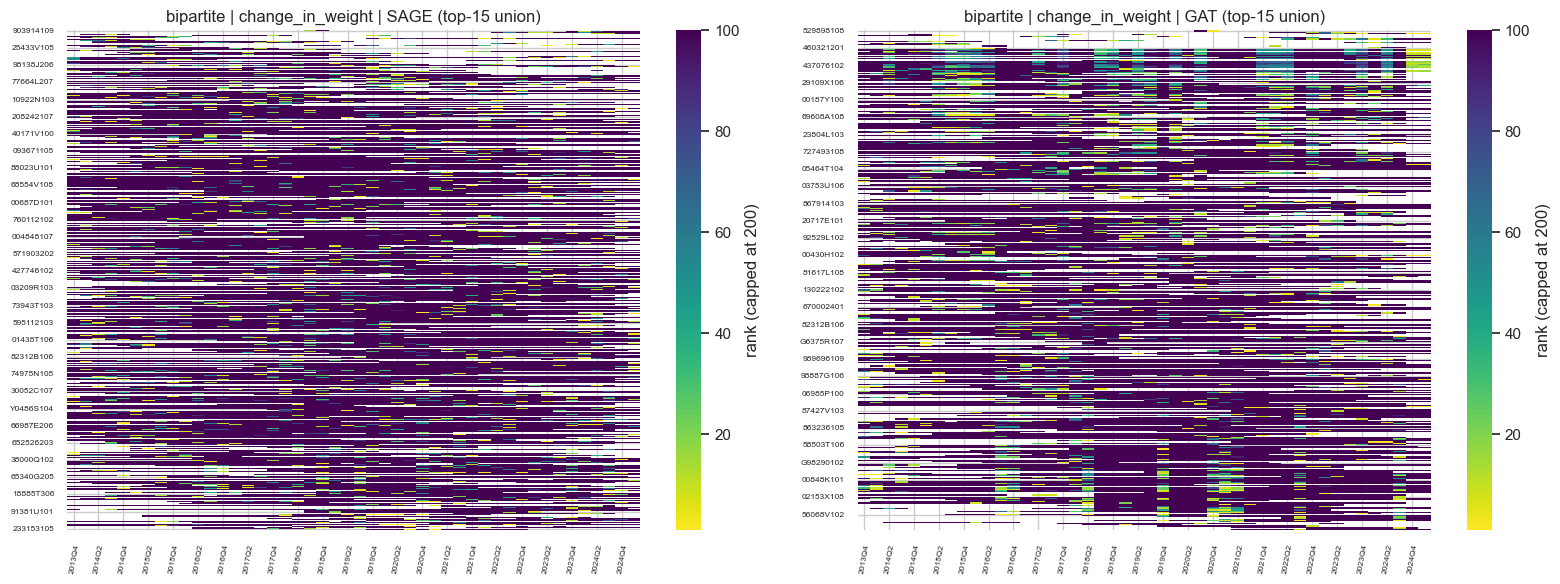

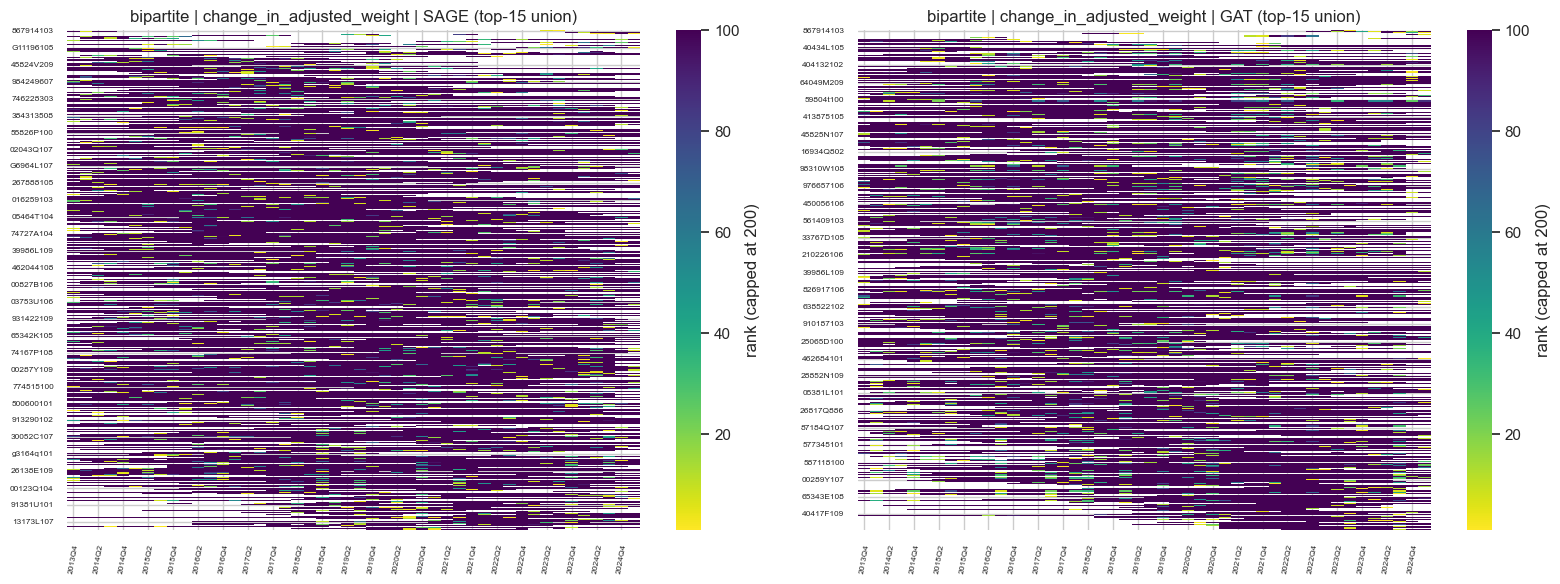

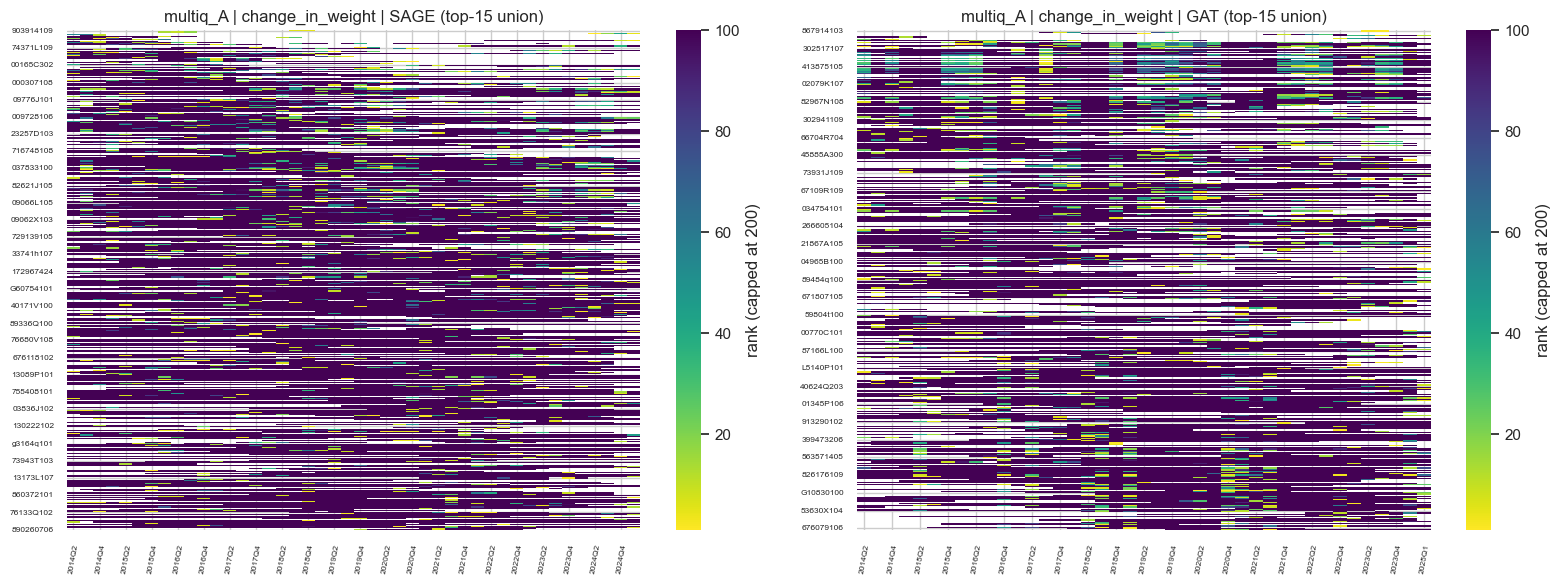

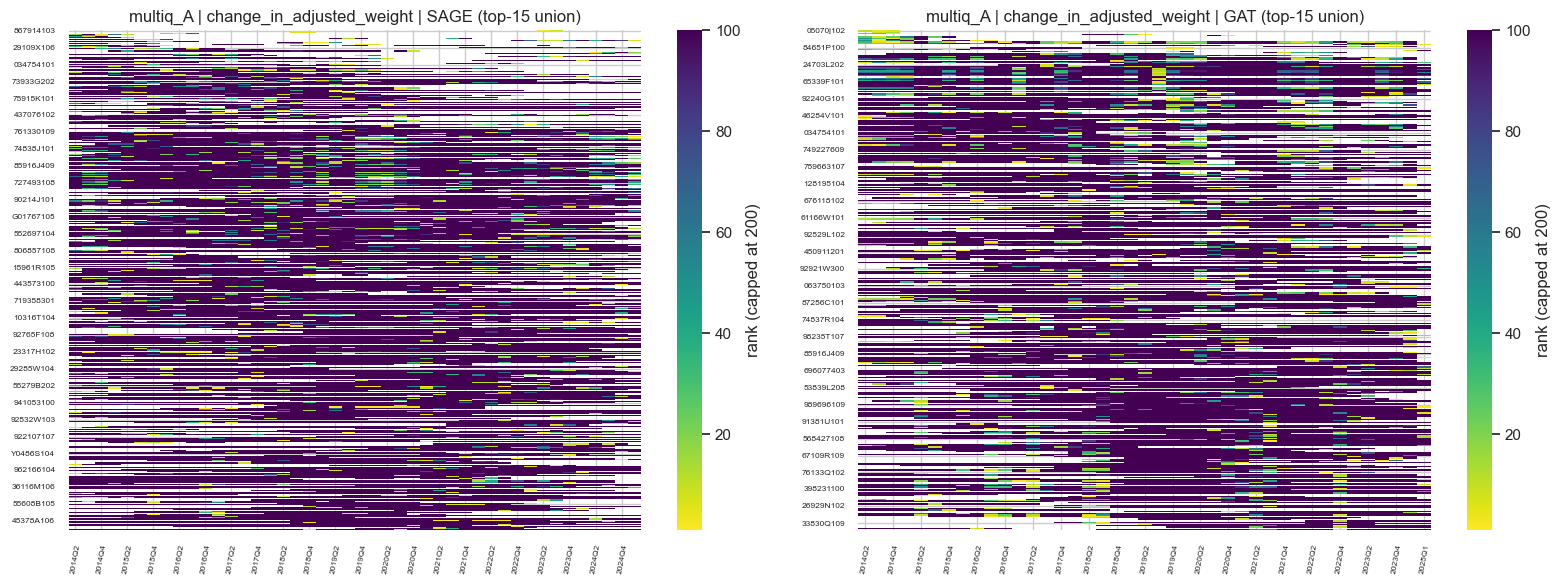

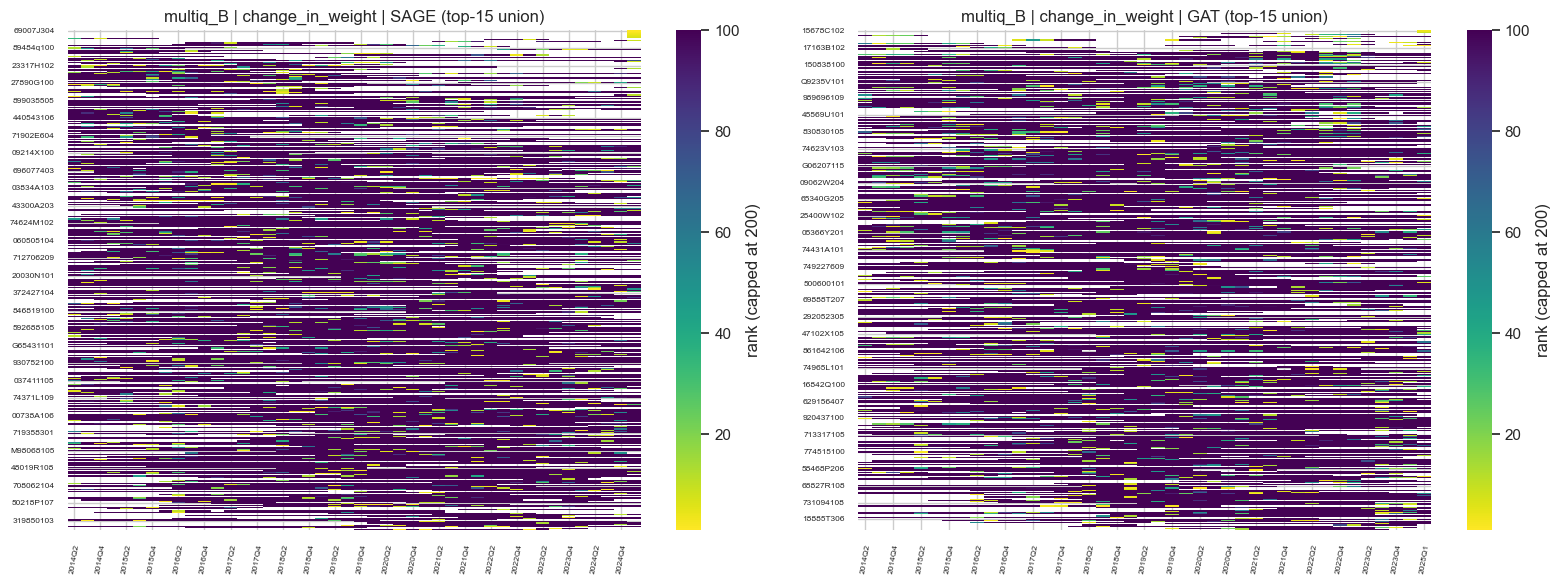

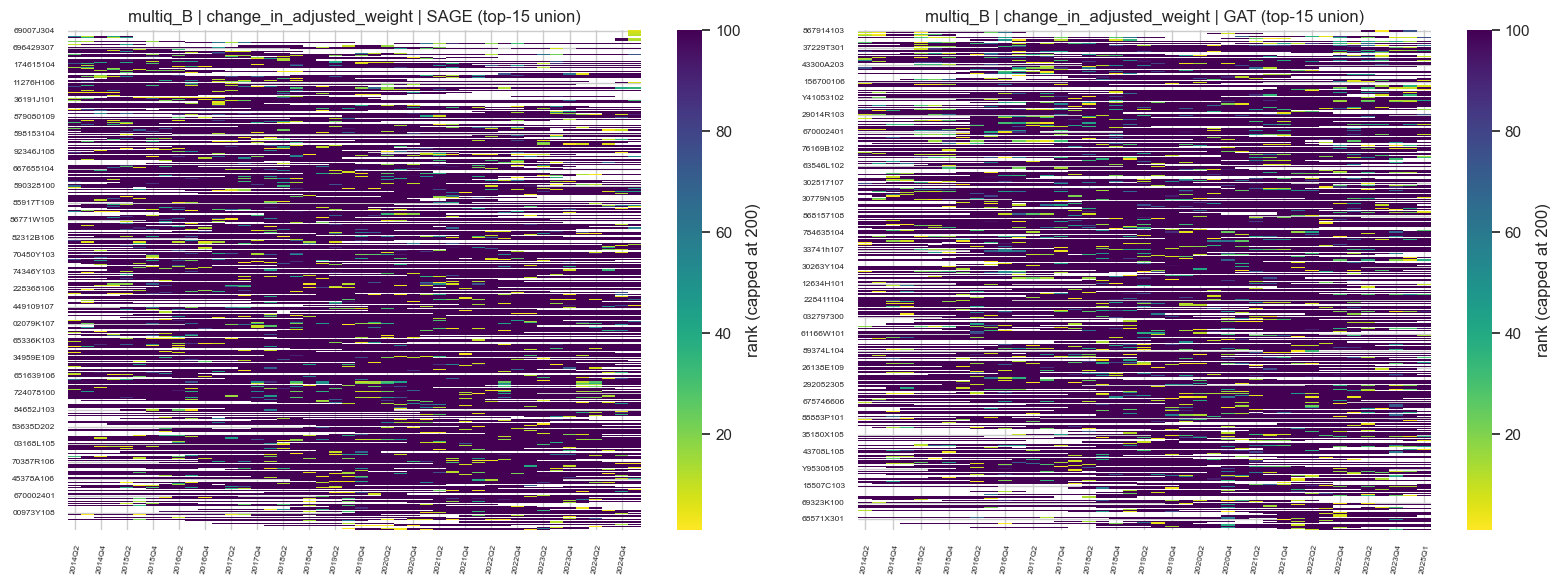

In [42]:
TOP_K_FOR_EVOLUTION = 15

def quarters_sorted(df):
    return sorted(df[["year", "quarter"]].drop_duplicates().itertuples(index=False, name=None))


def rank_heatmap(scores_df, model, top_k=TOP_K_FOR_EVOLUTION, ax=None):
    sub = scores_df[scores_df.model == model][["cusip", "year", "quarter", "rank"]]
    if sub.empty:
        ax.set_title("(no data)"); return None
    top_cusips = (sub[sub["rank"] <= top_k]["cusip"].drop_duplicates().tolist())
    pivot = (sub[sub["cusip"].isin(top_cusips)]
             .assign(q=lambda d: d["year"].astype(str) + "Q" + d["quarter"].astype(str))
             .pivot_table(index="cusip", columns="q", values="rank", aggfunc="min"))
    qcols = sorted(pivot.columns,
                    key=lambda s: (int(s.split("Q")[0]), int(s.split("Q")[1])))
    pivot = pivot[qcols]
    pivot["_mean"] = pivot.mean(axis=1, skipna=True)
    pivot = pivot.sort_values("_mean").drop(columns="_mean")
    sns.heatmap(pivot.clip(upper=100), ax=ax, cmap="viridis_r",
                cbar_kws={"label": "rank (capped at 200)"}, vmin=1, vmax=100)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=80, labelsize=6)
    ax.tick_params(axis="y", labelsize=6)
    return pivot


for approach in APPROACHES:
    for edges_col in EDGES_COLS:
        s = load_scores(approach, edges_col)
        if s.empty:
            continue
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        for ax, m in zip(axes, MODELS):
            rank_heatmap(s, m, ax=ax)
            ax.set_title(f"{approach} | {edges_col} | {m.upper()} (top-{TOP_K_FOR_EVOLUTION} union)")
        plt.tight_layout(); plt.show()

### 4.3 Per-CUSIP rank stability

For each (approach × edge_col × model), filter to CUSIPs that appear in at least
half the quarters, then compute mean rank, rank std, and how often each CUSIP
lands in top-10 / top-25 / top-50. Tabulates the 15 most stably-top CUSIPs per
corner — these are the names the model returns to repeatedly.

In [43]:
STABILITY_TOP_N = 15
MIN_QUARTERS_FRAC = 0.5

stability_rows = []
for approach in APPROACHES:
    for edges_col in EDGES_COLS:
        s = load_scores(approach, edges_col)
        if s.empty:
            continue
        for model in MODELS:
            sub = s[s.model == model]
            if sub.empty:
                continue
            n_total_q = sub[["year", "quarter"]].drop_duplicates().shape[0]
            min_q = max(2, int(n_total_q * MIN_QUARTERS_FRAC))
            grp = (sub.groupby("cusip")
                      .agg(n_quarters=("rank", "size"),
                           mean_rank=("rank", "mean"),
                           std_rank=("rank", "std"),
                           best_rank=("rank", "min"),
                           frac_top10=("rank", lambda r: (r <= 10).mean()),
                           frac_top25=("rank", lambda r: (r <= 25).mean()),
                           frac_top50=("rank", lambda r: (r <= 50).mean())))
            grp = grp[grp["n_quarters"] >= min_q]
            top = (grp.sort_values("mean_rank")
                       .head(STABILITY_TOP_N)
                       .reset_index())
            top.insert(0, "model", model)
            top.insert(0, "edges_col", edges_col)
            top.insert(0, "approach", approach)
            stability_rows.append(top)
stability_df = pd.concat(stability_rows, ignore_index=True) if stability_rows else pd.DataFrame()
print("rows:", len(stability_df))
stability_df.head(30)

rows: 180


,approach,edges_col,model,cusip,n_quarters,mean_rank,std_rank,best_rank,frac_top10,frac_top25,frac_top50
0,bipartite,change_in_weight,sage,65542W107,23,1016.173913,1051.687114,2,0.086957,0.130435,0.260870
1,bipartite,change_in_weight,sage,28414H103,26,1027.192308,733.606599,152,0.000000,0.000000,0.000000
2,bipartite,change_in_weight,sage,53071M104,33,1044.030303,885.032997,8,0.030303,0.060606,0.121212
3,bipartite,change_in_weight,sage,81362J100,24,1075.375000,930.824497,11,0.000000,0.041667,0.083333
4,bipartite,change_in_weight,sage,42225K106,26,1090.192308,935.106070,82,0.000000,0.000000,0.000000
5,bipartite,change_in_weight,sage,984249607,40,1093.975000,934.068396,5,0.050000,0.075000,0.100000
6,bipartite,change_in_weight,sage,45168K306,23,1105.565217,1042.504145,2,0.043478,0.043478,0.043478
7,bipartite,change_in_weight,sage,440543106,27,1120.925926,893.198528,7,0.037037,0.037037,0.111111
8,bipartite,change_in_weight,sage,004446100,25,1127.840000,885.142958,7,0.040000,0.040000,0.080000
9,bipartite,change_in_weight,sage,16679L109,23,1130.695652,817.756990,19,0.000000,0.043478,0.043478


In [ ]:
# Show one focused table per (approach, edges_col, model). Picks the bipartite
# corner first; scroll to see others.
if not stability_df.empty:
    for (a, c, m), grp in stability_df.groupby(["approach", "edges_col", "model"], sort=False):
        print(f"\n=== {a} | {c} | {m.upper()} — top-{STABILITY_TOP_N} most stably-ranked ===")
        cols = ["cusip", "n_quarters", "mean_rank", "std_rank", "best_rank",
                 "frac_top10", "frac_top25", "frac_top50"]
        print(grp[cols].round(3).to_string(index=False))


=== bipartite | change_in_weight | SAGE — top-15 most stably-ranked ===
    cusip  n_quarters  mean_rank  std_rank  best_rank  frac_top10  frac_top25  frac_top50
65542W107          23   1016.174  1051.687          2       0.087       0.130       0.261
28414H103          26   1027.192   733.607        152       0.000       0.000       0.000
53071M104          33   1044.030   885.033          8       0.030       0.061       0.121
81362J100          24   1075.375   930.824         11       0.000       0.042       0.083
42225K106          26   1090.192   935.106         82       0.000       0.000       0.000
984249607          40   1093.975   934.068          5       0.050       0.075       0.100
45168K306          23   1105.565  1042.504          2       0.043       0.043       0.043
440543106          27   1120.926   893.199          7       0.037       0.037       0.111
004446100          25   1127.840   885.143          7       0.040       0.040       0.080
16679L109          23   113

## 5. Top-N CUSIP picks vs realised next-quarter return

For each `(approach, edges_col, model)` and each quarter, take the top-N CUSIPs
by score (equivalently `rank ≤ N`) and join the realised `log_return` for that
CUSIP in `(next_year, next_quarter)`. Reports mean, std, and Sharpe-style
mean / std for N ∈ {10, 25, 50}.

In [26]:
stocks_path = DATA_DIR / "stocks_return.parquet"
if not stocks_path.exists():
    print(f"[skip] {stocks_path} not found — section 5 needs FGNN_DATA_DIR set.")
    stocks_return = None
else:
    stocks_return = pd.read_parquet(stocks_path)[["cusip", "year", "quarter", "log_return"]]
    print("stocks_return:", len(stocks_return))

[skip] C:\Users\potda\13Fgnn\data\stocks_return.parquet not found — section 5 needs FGNN_DATA_DIR set.


In [27]:
def next_q(y, q):
    return (y + 1, 1) if q == 4 else (y, q + 1)


def topn_return(scores_df, sr, N):
    """For each (year, quarter): take top-N by rank; realise log_return at (next_year, next_quarter)."""
    rows = []
    for (y, q), grp in scores_df.groupby(["year", "quarter"]):
        ny, nq = next_q(int(y), int(q))
        if "rank" in grp.columns:
            top = grp[grp["rank"] <= N][["cusip"]]
        else:
            top = grp.sort_values("score", ascending=False).head(N)[["cusip"]]
        merge = top.merge(
            sr[(sr["year"] == ny) & (sr["quarter"] == nq)],
            on="cusip", how="inner")
        if merge.empty:
            continue
        rows.append({
            "year": int(y), "quarter": int(q),
            "n_matched": len(merge),
            "mean_return": merge["log_return"].mean(),
            "std_return":  merge["log_return"].std(),
        })
    return pd.DataFrame(rows)


topn_summary_rows = []
if stocks_return is not None:
    for a, c, m in product(APPROACHES, EDGES_COLS, MODELS):
        s = load_scores(a, c)
        if s.empty:
            continue
        s = s[s.model == m]
        for N in [10, 25, 50]:
            df = topn_return(s, stocks_return, N)
            if df.empty:
                continue
            mr = df["mean_return"].mean()
            sd = df["mean_return"].std()
            topn_summary_rows.append({
                "approach": a, "edges_col": c, "model": m, "N": N,
                "avg_return":  mr,
                "std_across_quarters": sd,
                "sharpe_like": mr / sd if sd and sd > 0 else np.nan,
                "n_quarters":  len(df),
            })
topn_summary = pd.DataFrame(topn_summary_rows).round(4)
topn_summary

""


## 6. LightGCN V4 results

Loaded from `python_files/results/LightGcnV4/`. V4 was trained as a recommendation
model (BPR loss on fund→stock edges); it predicts P(top-stock for next quarter)
instead of tertile classes, so its primary metrics are AUC / AP / hit@K /
NDCG@K rather than accuracy. V4 only ran with `change_in_weight`.

### 6.1 Per-quarter classification metrics (AUC, AP, F1@opt)

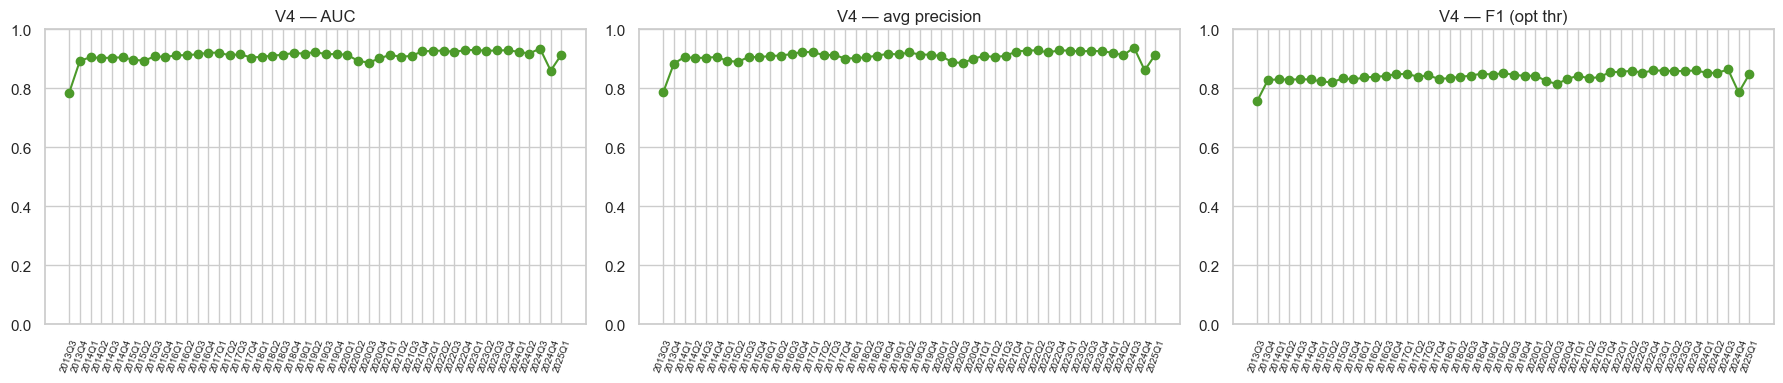

In [28]:
if v4_metrics.empty:
    print("[skip] no V4 metrics found.")
else:
    v4 = v4_metrics.sort_values(["year", "quarter"]).copy()
    v4["q"] = v4["year"].astype(str) + "Q" + v4["quarter"].astype(str)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    for ax, col, title in zip(axes,
                                ["test_auc", "test_avg_precision", "test_f1_opt"],
                                ["AUC", "avg precision", "F1 (opt thr)"]):
        ax.plot(v4["q"], v4[col], marker="o", color="#4c9a2a")
        ax.set_title(f"V4 — {title}")
        ax.tick_params(axis="x", rotation=70, labelsize=7)
        ax.set_ylim(0, 1)
    plt.tight_layout(); plt.show()
    v4[["q", "test_auc", "test_avg_precision", "test_f1_opt", "opt_threshold", "epochs_trained"]].head(10)

### 6.2 Hit@K and NDCG@K (K ∈ {5, 10, 20, 50})

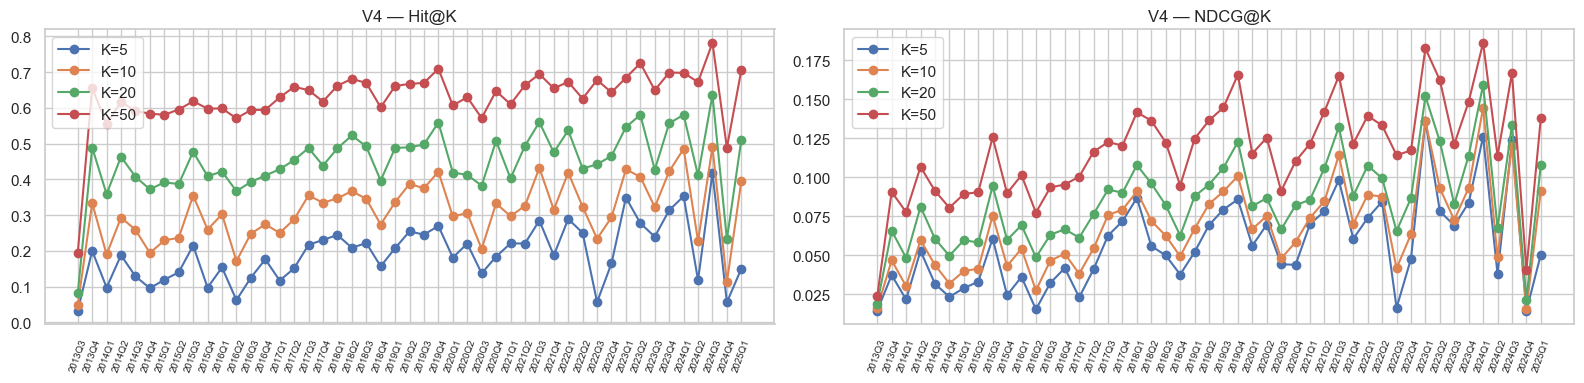

V4 means:
test_auc                0.910
hit5                    0.192
hit10                   0.309
hit20                   0.450
hit50                   0.630
ndcg5                   0.056
ndcg10                  0.067
ndcg20                  0.084
ndcg50                  0.117
rank_return_spearman    0.025


In [29]:
if not v4_metrics.empty:
    v4 = v4_metrics.sort_values(["year", "quarter"]).copy()
    v4["q"] = v4["year"].astype(str) + "Q" + v4["quarter"].astype(str)
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
    for ax, prefix, title in zip(axes, ["hit", "ndcg"], ["Hit@K", "NDCG@K"]):
        for K in [5, 10, 20, 50]:
            col = f"{prefix}{K}"
            if col in v4.columns:
                ax.plot(v4["q"], v4[col], marker="o", label=f"K={K}")
        ax.set_title(f"V4 — {title}")
        ax.tick_params(axis="x", rotation=70, labelsize=7)
        ax.legend()
    plt.tight_layout(); plt.show()
    print("V4 means:")
    cols = [c for c in v4.columns if c.startswith("hit") or c.startswith("ndcg") or c == "test_auc" or c == "rank_return_spearman"]
    print(v4[cols].mean().round(3).to_string())

### 6.3 Top-N realised return for V4

Same helper as § 5, applied to the V4 ranks (after renaming `mean_score` → `score`
in `load_v4_scores`). Comparable to the SAGE/GAT rows in `topn_summary`.

In [30]:
v4_topn_rows = []
v4_scores = load_v4_scores()
if stocks_return is not None and not v4_scores.empty:
    for N in [10, 25, 50]:
        df = topn_return(v4_scores, stocks_return, N)
        if df.empty:
            continue
        mr = df["mean_return"].mean()
        sd = df["mean_return"].std()
        v4_topn_rows.append({
            "approach": "v4_lightgcn", "edges_col": "change_in_weight",
            "model": "v4", "N": N,
            "avg_return": mr,
            "std_across_quarters": sd,
            "sharpe_like": mr / sd if sd and sd > 0 else np.nan,
            "n_quarters": len(df),
        })
v4_topn = pd.DataFrame(v4_topn_rows).round(4)
v4_topn

""


## 7. Cross-model comparison: SAGE vs GAT vs LightGCN V4

Restrict to the **bipartite × change_in_weight** corner — the only one where all
three models exist with the same input edges. Inner-join SAGE, GAT, and V4 ranks
on `(cusip, year, quarter)` and compute pairwise Spearman ρ and top-25 overlap
per quarter; aggregate across quarters.

In [31]:
def topk_overlap_lists(a_list, b_list, k):
    return len(set(a_list[:k]) & set(b_list[:k])) / k


cross_rows = []
if not v4_metrics.empty:
    s = load_scores("bipartite", "change_in_weight")
    v4 = load_v4_scores()
    if not s.empty and not v4.empty:
        s_sage = s[s.model == "sage"][["cusip", "year", "quarter", "rank", "score"]]
        s_gat  = s[s.model == "gat" ][["cusip", "year", "quarter", "rank", "score"]]
        v4_min = v4[["cusip", "year", "quarter", "rank", "score"]]
        quarters = sorted(set(zip(s_sage.year, s_sage.quarter)) &
                            set(zip(s_gat.year, s_gat.quarter)) &
                            set(zip(v4_min.year, v4_min.quarter)))
        for y, q in quarters:
            a = s_sage[(s_sage.year == y) & (s_sage.quarter == q)]
            b = s_gat [(s_gat.year  == y) & (s_gat.quarter  == q)]
            v = v4_min[(v4_min.year == y) & (v4_min.quarter == q)]
            m = (a.merge(b, on="cusip", suffixes=("_sage", "_gat"))
                  .merge(v.rename(columns={"rank": "rank_v4", "score": "score_v4"}), on="cusip"))
            if len(m) < 5:
                continue
            row = {"year": y, "quarter": q, "n": len(m)}
            row["rho_sage_gat"] = spearmanr(m["score_sage"], m["score_gat"]).statistic
            row["rho_sage_v4"] = spearmanr(m["score_sage"], m["score_v4"]).statistic
            row["rho_gat_v4"]  = spearmanr(m["score_gat"],  m["score_v4"]).statistic
            sage_sorted = a.sort_values("score", ascending=False)["cusip"].tolist()
            gat_sorted  = b.sort_values("score", ascending=False)["cusip"].tolist()
            v4_sorted   = v.sort_values("score", ascending=False)["cusip"].tolist()
            row["top25_sage_gat"] = topk_overlap_lists(sage_sorted, gat_sorted, 25)
            row["top25_sage_v4"] = topk_overlap_lists(sage_sorted, v4_sorted,  25)
            row["top25_gat_v4"]  = topk_overlap_lists(gat_sorted,  v4_sorted,  25)
            cross_rows.append(row)
cross_df = pd.DataFrame(cross_rows)
if cross_df.empty:
    print("no overlapping quarters for cross-model comparison")
    cross_summary = pd.DataFrame()
else:
    cross_summary = (cross_df.drop(columns=["year", "quarter", "n"])
                              .agg(["mean", "std"]).round(3))
    print(f"overlapping quarters: {len(cross_df)}")
cross_summary

overlapping quarters: 46


,rho_sage_gat,rho_sage_v4,rho_gat_v4,top25_sage_gat,top25_sage_v4,top25_gat_v4
mean,0.293,0.040,0.195,0.183,0.027,0.014
std,0.593,0.484,0.546,0.169,0.074,0.083


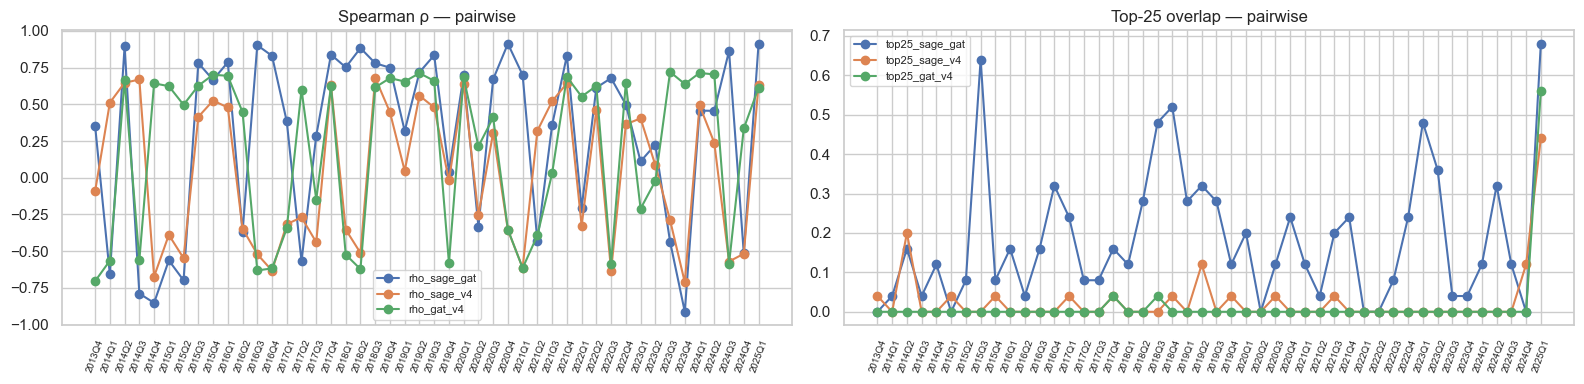

In [32]:
if not cross_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4), sharex=True)
    cross_df = cross_df.sort_values(["year", "quarter"])
    cross_df["q"] = cross_df["year"].astype(str) + "Q" + cross_df["quarter"].astype(str)
    for ax, cols, title in zip(
        axes,
        [["rho_sage_gat", "rho_sage_v4", "rho_gat_v4"],
         ["top25_sage_gat", "top25_sage_v4", "top25_gat_v4"]],
        ["Spearman ρ — pairwise", "Top-25 overlap — pairwise"]):
        for c in cols:
            ax.plot(cross_df["q"], cross_df[c], marker="o", label=c)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=70, labelsize=7)
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## 8. Overall summary

One row per `(approach, edges_col, model)` for SAGE/GAT plus one row for
LightGCN V4 — combined into a single table for at-a-glance comparison.

In [33]:
rows = []
for a, c, m in product(APPROACHES, EDGES_COLS, MODELS):
    d = all_metrics[(all_metrics.approach == a) &
                      (all_metrics.edges_col == c)]
    if d.empty:
        continue
    row = {
        "approach": a, "edges_col": c, "model": m,
        "n_quarters": int(d[f"{m}_acc"].notna().sum()),
        "acc_mean": d[f"{m}_acc"].mean(),
        "f1_mean":  d[f"{m}_f1"].mean(),
        "acc_std":  d[f"{m}_acc"].std(),
    }
    if not agree_df.empty:
        ov = agree_df[(agree_df.approach == a) & (agree_df.edges_col == c)]["top25"].mean()
        row["top25_sage_vs_gat"] = ov
    if topn_summary_rows:
        ts = topn_summary[(topn_summary.approach == a) &
                            (topn_summary.edges_col == c) &
                            (topn_summary.model == m) &
                            (topn_summary.N == 25)]["avg_return"]
        row["top25_avg_return"] = ts.iloc[0] if not ts.empty else np.nan
    rows.append(row)
if not v4_metrics.empty:
    v4r = {
        "approach": "v4_lightgcn", "edges_col": "change_in_weight", "model": "v4",
        "n_quarters": len(v4_metrics),
        "acc_mean":   v4_metrics["test_auc"].mean(),  # AUC, not accuracy
        "f1_mean":    v4_metrics["test_f1_opt"].mean(),
        "acc_std":    v4_metrics["test_auc"].std(),
    }
    if not v4_topn.empty:
        ts = v4_topn[v4_topn.N == 25]["avg_return"]
        v4r["top25_avg_return"] = ts.iloc[0] if not ts.empty else np.nan
    rows.append(v4r)
overall = pd.DataFrame(rows).round(4)
print(f"corners: {len(overall)} (12 sage/gat + up to 1 v4 = 13 expected)")
print("NOTE: v4_lightgcn 'acc_mean' column carries AUC, not classification accuracy — different task.")
overall

corners: 13 (12 sage/gat + up to 1 v4 = 13 expected)
NOTE: v4_lightgcn 'acc_mean' column carries AUC, not classification accuracy — different task.


,approach,edges_col,model,n_quarters,acc_mean,f1_mean,acc_std,top25_sage_vs_gat
0,bipartite,change_in_weight,sage,46,0.4018,0.3851,0.0430,0.1835
1,bipartite,change_in_weight,gat,46,0.3629,0.3131,0.0344,0.1835
2,bipartite,change_in_adjusted_weight,sage,46,0.4015,0.3862,0.0425,0.1643
3,bipartite,change_in_adjusted_weight,gat,46,0.3644,0.3186,0.0339,0.1643
4,multiq_A,change_in_weight,sage,44,0.4152,0.4012,0.0423,0.1707
5,multiq_A,change_in_weight,gat,41,0.3710,0.3336,0.0351,0.1707
6,multiq_A,change_in_adjusted_weight,sage,44,0.4150,0.3999,0.0401,0.1444
7,multiq_A,change_in_adjusted_weight,gat,41,0.3709,0.3353,0.0322,0.1444
8,multiq_B,change_in_weight,sage,44,0.3870,0.3745,0.0460,0.1112
9,multiq_B,change_in_weight,gat,41,0.3557,0.3100,0.0344,0.1112


## 9. Overall statistics phase — plain-language digest

Pulls already-computed numbers from sections 2-8 into a one-paragraph bulleted
digest. Useful as the executive summary you can paste into a writeup.

In [34]:
def fmt_pct(x):
    return "--" if pd.isna(x) else f"{x*100:.1f}%"
def fmt_num(x, p=4):
    return "--" if pd.isna(x) else f"{x:.{p}f}"

lines = []
lines.append("### Overall digest")
lines.append("")
# best (approach, edge_col, model) by mean accuracy among sage/gat
sg_only = overall[overall.model.isin(MODELS)]
if not sg_only.empty:
    best = sg_only.sort_values("acc_mean", ascending=False).iloc[0]
    lines.append(f"- **Best SAGE/GAT corner by mean accuracy**: `{best.approach}` × `{best.edges_col}` × **{best.model.upper()}** = {fmt_num(best.acc_mean)} (chance = 0.333)")
# how often does GAT beat SAGE per corner?
if not summary_2.empty:
    won = (summary_2["diff_mean"] > 0).sum()
    total = len(summary_2)
    lines.append(f"- **GAT > SAGE in {won} of {total} corners** (mean Δ across corners = {fmt_num(summary_2['diff_mean'].mean())}); paired-t p-values: {[fmt_num(p, 3) for p in summary_2['t_pvalue']]}")
# average sage-vs-gat top-25 overlap
if not agree_df.empty:
    lines.append(f"- **SAGE vs GAT top-25 ranking overlap**: mean = {fmt_pct(agree_df['top25'].mean())}, mean Spearman ρ = {fmt_num(agree_df['spearman'].mean(), 3)}")
# best top-25 realised return among sage/gat/v4
ranked_returns = []
if topn_summary_rows:
    ranked_returns.append(topn_summary[topn_summary.N == 25])
if v4_topn_rows:
    ranked_returns.append(v4_topn[v4_topn.N == 25])
if ranked_returns:
    rr = pd.concat(ranked_returns, ignore_index=True).sort_values("avg_return", ascending=False)
    if not rr.empty:
        bw = rr.iloc[0]
        lines.append(f"- **Best top-25 realised return**: `{bw.approach}` × `{bw.edges_col}` × **{str(bw.model).upper()}** → mean log-return = {fmt_num(bw.avg_return)} per quarter (n={int(bw.n_quarters)} quarters)")
# v4 headline
if not v4_metrics.empty:
    lines.append(f"- **LightGCN V4** (single corner, change_in_weight): mean test_auc = {fmt_num(v4_metrics['test_auc'].mean(), 3)}, mean NDCG@10 = {fmt_num(v4_metrics['ndcg10'].mean(), 3)}, mean hit@10 = {fmt_pct(v4_metrics['hit10'].mean())}")
# v4 vs sage/gat on shared corner
if 'cross_summary' in dir() and not cross_summary.empty:
    means = cross_summary.loc["mean"]
    lines.append(f"- **Cross-model agreement on bipartite × change_in_weight (n={len(cross_df)} quarters)**: ρ_sage_gat={fmt_num(means.get('rho_sage_gat'), 3)}, ρ_sage_v4={fmt_num(means.get('rho_sage_v4'), 3)}, ρ_gat_v4={fmt_num(means.get('rho_gat_v4'), 3)}; top-25 overlaps={fmt_pct(means.get('top25_sage_gat'))} / {fmt_pct(means.get('top25_sage_v4'))} / {fmt_pct(means.get('top25_gat_v4'))}")
# coverage caveat
missing_gat = sg_only[(sg_only.model == "gat") & (sg_only.n_quarters < sg_only.n_quarters.max())]
if not missing_gat.empty:
    lines.append("- **Coverage caveat**: GAT is missing 3 quarters per `multiq_*` corner (2024Q2/Q3/Q4) due to RTX-3090 OOM; see `KNOWN_ISSUES.md` for the retry recipe.")

from IPython.display import Markdown
Markdown("\n".join(lines))

### Overall digest

- **Best SAGE/GAT corner by mean accuracy**: `multiq_A` × `change_in_weight` × **SAGE** = 0.4152 (chance = 0.333)
- **GAT > SAGE in 0 of 6 corners** (mean Δ across corners = -0.0383); paired-t p-values: ['0.000', '0.000', '0.000', '0.000', '0.000', '0.000']
- **SAGE vs GAT top-25 ranking overlap**: mean = 14.3%, mean Spearman ρ = 0.219
- **LightGCN V4** (single corner, change_in_weight): mean test_auc = 0.910, mean NDCG@10 = 0.067, mean hit@10 = 30.9%
- **Cross-model agreement on bipartite × change_in_weight (n=46 quarters)**: ρ_sage_gat=0.293, ρ_sage_v4=0.040, ρ_gat_v4=0.195; top-25 overlaps=18.3% / 2.7% / 1.4%
- **Coverage caveat**: GAT is missing 3 quarters per `multiq_*` corner (2024Q2/Q3/Q4) due to RTX-3090 OOM; see `KNOWN_ISSUES.md` for the retry recipe.

## 10. Model descriptions & core principles

How each model learns and trains, in compact form.

---

### WeightedSAGE — graph-based mean aggregation

**Core principle**: a node's representation is the *average* of its neighbours'
representations, transformed by a small MLP. No attention, no edge weighting in
the v1 variant — every neighbour contributes equally.

**Layer update** (per `SAGEConv`):
$$h_v^{(\ell+1)} = \sigma\left( W^{(\ell)} \cdot \mathrm{MEAN}\left( \{h_v^{(\ell)}\} \cup \{h_u^{(\ell)} : u \in \mathcal{N}(v)\} \right) \right)$$

**Architecture**: 2 layers, hidden dim 64, dropout 0.5 between layers, linear
head to 3 logits.

**Training recipe**:
- **Task**: 3-way tertile classification — for stock nodes, the label is the
  tertile of next-quarter `log_return`; for fund nodes, the tertile of
  next-quarter weighted holdings profitability.
- **Loss**: cross-entropy on labelled nodes (stocks + funds with valid labels).
- **Optimiser**: Adam, lr=8e-4, weight_decay=5e-4.
- **Epochs**: 150, with best-val-acc snapshotting (CPU-stored state).
- **Inference**: softmax → P(top tertile) is the score; CUSIPs ranked by P(top).

**What makes it tick**: collaborative-filtering style — funds and stocks that
share many holdings get pulled toward the same tertile. Fast; few parameters.

---

### WeightedGAT — multi-head attention

**Core principle**: not all neighbours are equally informative; learn a
data-dependent attention coefficient per edge that weights neighbour messages.

**Layer update** (per `GATConv`, h heads):
$$\alpha_{v,u} = \mathrm{softmax}_u\left(\mathrm{LeakyReLU}\left(\mathbf{a}^\top [W h_v \,\|\, W h_u]\right)\right)$$
$$h_v^{(\ell+1)} = \bigg\Vert_{k=1}^{h} \sigma\left( \sum_{u \in \mathcal{N}(v) \cup \{v\}} \alpha^k_{v,u} W^k h_u^{(\ell)} \right)$$

Heads are concatenated in middle layers; the final layer averages heads
(`heads=1, concat=False`).

**Architecture**: 2 layers, hidden 64, 4 heads, dropout 0.5, ELU between layers,
linear head to 3 logits. The v1 variant ignores edge weights / `edge_attr` —
attention is learned purely from node features.

**Training recipe**: same task, loss, optimiser, and epochs as SAGE.

**What makes it tick**: attention can up-weight neighbours that match the target
and down-weight outliers. More expressive than SAGE; more memory-hungry on big
graphs (attention coefficients × heads × edges).

---

### LightGCN V4 — embedding-only collaborative filtering

**Core principle**: drop the feature transformations and non-linearities that
GCN/SAGE/GAT use. The only learned parameters are the **node embeddings**;
propagation just averages neighbour embeddings with degree normalisation.

**Layer update**:
$$e_u^{(k+1)} = \sum_{v \in \mathcal{N}(u)} \frac{1}{\sqrt{|\mathcal{N}_u| \cdot |\mathcal{N}_v|}}\, e_v^{(k)}$$

**Final embedding**: weighted sum across all K layers,
$e_u = \sum_{k=0}^{K} \beta_k e_u^{(k)}$ (with $\beta_k = 1/(K+1)$ in V4).

**Score**: dot product of fund embedding and stock embedding;
in this sweep, per-CUSIP score is the **mean** dot product across all funds, so
high-scoring CUSIPs are stocks that many fund embeddings point toward.

**Architecture**: embed_dim 128, 3 propagation layers, no MLP, no dropout.

**Training recipe**:
- **Task**: BPR ranking — for each (fund, +stock, −stock) triple, push
  $\sigma(\hat r_{u,+} - \hat r_{u,-})$ toward 1.
- **Triples**: positive = fund→stock edge with `change_in_weight > 0`; negative
  = uniformly-sampled stock the fund didn't buy that quarter.
- **Optimiser**: Adam (V4 default lr); ~90 epochs.
- **Inference**: rank stocks by mean predicted score across funds.

**Reported metrics**: AUC, average precision, F1@opt-threshold, hit@K, NDCG@K,
Spearman of model rank vs realised next-quarter return — these are *recommender*
metrics, not classification accuracy, hence the column-name asymmetry in § 8.

**What makes it tick**: very few parameters, trains fast, works well when the
user-item (fund-stock) bipartite graph is dense and recurrent. Doesn't use node
features at all, which is both a strength (robust to noisy features) and a
weakness (can't transfer to unseen CUSIPs without prior holdings).